# Stitching redesign, step 2: reject failed edges

Some edges measure noise: little tissue or few beads in the overlap. Per
direction, drop an edge whose residual (measured - nominal) lies far from
that direction's typical residual: more than median + 5 x 1.4826 x MAD.

In [1]:
import os, sys, json, time, shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import LineCollection

# notebooks/tests/<subfolder>/ is three levels under the repo root.
MERCI_DIR = Path(os.getcwd()).parent.parent.parent
sys.path.insert(0, str(MERCI_DIR / "src"))
sys.path.insert(0, os.getcwd())
import stitching_redesign_lib as L

NOTEBOOK_NAME = "stitching_redesign_step_02_reject_outliers"
# Local data copy shared by every stitching_redesign_step_NN notebook
# (written by step 01; source: BC555_sample_05/epi, cells round).
DATA_DIR = MERCI_DIR / "cache" / "2026_09_25_1336" / "stitching_redesign" / "data"
FIG_DIR = MERCI_DIR / "cache" / "2026_09_25_1336" / "explanation" / "figures" / NOTEBOOK_NAME
DATA_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

TITLE_FS, LABEL_FS, TICK_FS, LEGEND_FS = 14, 12, 11, 10
plt.rcParams.update({"axes.titlesize": TITLE_FS, "axes.labelsize": LABEL_FS,
                     "xtick.labelsize": TICK_FS, "ytick.labelsize": TICK_FS,
                     "legend.fontsize": LEGEND_FS})
DIR_COLORS = {"right": "#1f77b4", "left": "#ff7f0e", "up": "#2ca02c", "down": "#d62728"}


def save(fig, stem):
    path = FIG_DIR / f"{stem}.png"
    fig.savefig(path, dpi=110, bbox_inches="tight")
    print("saved", path.relative_to(MERCI_DIR))


In [2]:
geom = json.loads((DATA_DIR / "geometry.json").read_text())
PX, STEP, FRAME = geom["pixel_um"], geom["step_um"], geom["frame_px"]
nominal = np.loadtxt(DATA_DIR / "positions.txt", delimiter=",")
NBHD = np.array(geom["neighbourhood"])          # 3x3 FOV ids, row 0 = top
new_df = pd.read_csv(DATA_DIR / "edges_remeasured.csv")
edges = L.Edges(new_df, nominal)
print(f"{len(nominal)} FOVs, {len(new_df)} edges, pixel {PX} um, step {STEP:.3f} um, "
      f"3x3 centre FOV {NBHD[1, 1]}")


476 FOVs, 894 edges, pixel 0.109 um, step 199.066 um, 3x3 centre FOV 221


In [3]:
def draw_edges(ax, P, idx, values, cmap, vmin, vmax, lw=2.0):
    """Segments between FOV centres for edges idx, coloured by values."""
    half = FRAME * PX / 2
    seg = np.stack([P[edges.i[idx]] + half, P[edges.j[idx]] + half], axis=1)
    lc = LineCollection(seg, cmap=cmap, linewidths=lw)
    lc.set_array(np.asarray(values)); lc.set_clim(vmin, vmax)
    ax.add_collection(lc)
    ax.set_xlim(P[:, 0].min() - 100, P[:, 0].max() + FRAME * PX + 100)
    ax.set_ylim(P[:, 1].min() - 100, P[:, 1].max() + FRAME * PX + 100)
    ax.set_aspect("equal")
    return lc


def mark_nbhd(ax, P, color="k"):
    """Outline the 3x3 neighbourhood on a whole-grid plot."""
    ids = NBHD.ravel()
    x0, y0 = P[ids, 0].min(), P[ids, 1].min()
    x1, y1 = P[ids, 0].max() + FRAME * PX, P[ids, 1].max() + FRAME * PX
    ax.add_patch(mpatches.Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False, ec=color, lw=2, ls="--"))


def draw_boxes(ax, P, color, lw=0.6, alpha=1.0):
    for p in P:
        ax.add_patch(mpatches.Rectangle(p, FRAME * PX, FRAME * PX, fill=False, ec=color, lw=lw, alpha=alpha))
    ax.set_xlim(P[:, 0].min() - 100, P[:, 0].max() + FRAME * PX + 100)
    ax.set_ylim(P[:, 1].min() - 100, P[:, 1].max() + FRAME * PX + 100)
    ax.set_aspect("equal")


In [4]:
N_MAD = 5.0
keep = L.reject_outliers(edges, N_MAD)
np.save(DATA_DIR / "keep.npy", keep)
print(f"rejected {(~keep).sum()} / {len(keep)} edges")
print("rejected per direction:", pd.Series(edges.direction[~keep]).value_counts().to_dict())
print(f"band Pearson median: kept {np.median(new_df.pearson[keep]):.3f}, "
      f"rejected {np.median(new_df.pearson[~keep]):.3f}")
for n_mad in (3, 4, 5, 7, 10):
    print(f"  N_MAD={n_mad:>2}: rejects {(~L.reject_outliers(edges, n_mad)).sum()}")

rejected 32 / 894 edges
rejected per direction: {'up': 25, 'down': 7}
band Pearson median: kept 0.759, rejected 0.687
  N_MAD= 3: rejects 51
  N_MAD= 4: rejects 43
  N_MAD= 5: rejects 32
  N_MAD= 7: rejects 14
  N_MAD=10: rejects 1


saved cache/2026_09_25_1336/explanation/figures/stitching_redesign_step_02_reject_outliers/outliers.png


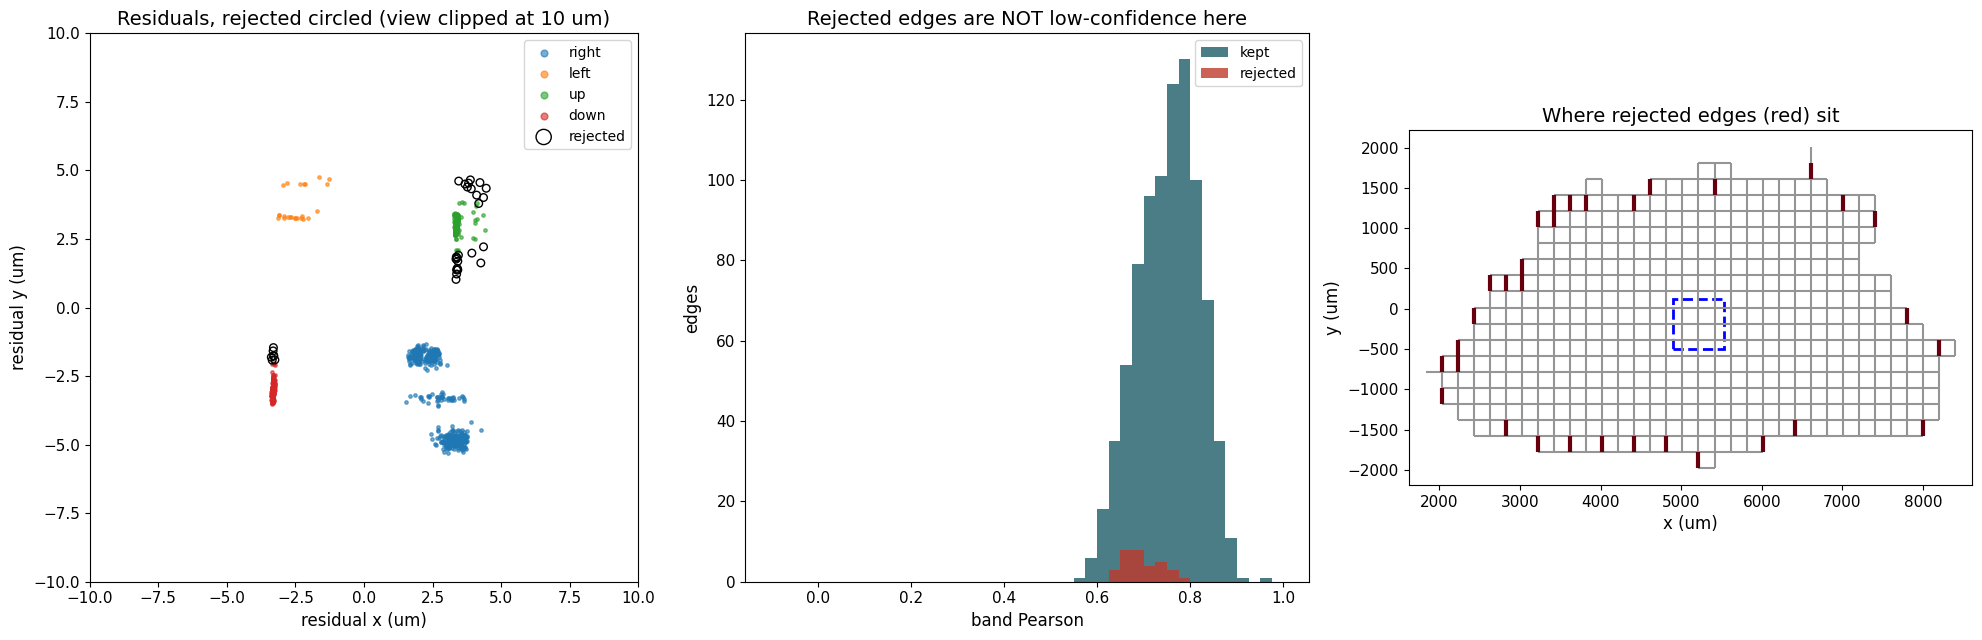

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(20, 6.5))
for dname, col in DIR_COLORS.items():
    s = (edges.direction == dname)
    ax[0].scatter(edges.r[s & keep, 0], edges.r[s & keep, 1], s=6, color=col, alpha=0.6, label=dname)
ax[0].scatter(edges.r[~keep, 0], edges.r[~keep, 1], s=30, facecolors="none", edgecolors="k", label="rejected")
ax[0].set_xlim(-10, 10); ax[0].set_ylim(-10, 10); ax[0].set_aspect("equal")
ax[0].set_xlabel("residual x (um)"); ax[0].set_ylabel("residual y (um)"); ax[0].legend(markerscale=2)
ax[0].set_title("Residuals, rejected circled (view clipped at 10 um)")
bins = np.linspace(-0.1, 1, 45)
ax[1].hist(new_df.pearson[keep], bins=bins, alpha=0.8, label="kept", color="#1d5c68")
ax[1].hist(new_df.pearson[~keep], bins=bins, alpha=0.8, label="rejected", color="#c0392b")
ax[1].set_xlabel("band Pearson"); ax[1].set_ylabel("edges"); ax[1].legend()
ax[1].set_title("Rejected edges are NOT low-confidence here")
draw_edges(ax[2], nominal, np.where(keep)[0], np.zeros(keep.sum()), "Greys", -1, 1, lw=1.5)
draw_edges(ax[2], nominal, np.where(~keep)[0], np.ones((~keep).sum()), "Reds", 0, 1, lw=3)
mark_nbhd(ax[2], nominal, "b"); ax[2].set_title("Where rejected edges (red) sit")
ax[2].set_xlabel("x (um)"); ax[2].set_ylabel("y (um)")
fig.tight_layout(); save(fig, "outliers")

In [6]:
# Where are the rejected edges? Column = x index; ids increase along the scan.
col = np.round((nominal[:, 0] - nominal[:, 0].min()) / STEP).astype(int)
end2, first = set(), set()
for c in np.unique(col):
    ids = np.sort(np.where(col == c)[0])
    end2 |= set(ids[:2]) | set(ids[-2:]); first.add(ids[0])
vert_kept = keep & np.isin(edges.direction, ["up", "down"])
at_end = np.array([(a in end2 and b in end2) for a, b in zip(edges.i, edges.j)])
at_first = np.array([(a in first or b in first) for a, b in zip(edges.i, edges.j)])
print(f"edge between the first two or last two FOVs of a column: rejected {at_end[~keep].mean():.2f}, "
      f"kept vertical {at_end[vert_kept].mean():.2f}")
print(f"edge touching a column's first-scanned FOV: rejected {at_first[~keep].mean():.2f}, "
      f"kept vertical {at_first[vert_kept].mean():.2f}")

edge between the first two or last two FOVs of a column: rejected 1.00, kept vertical 0.08
edge touching a column's first-scanned FOV: rejected 0.81, kept vertical 0.06


## Notes (numbers quoted by the HTML)

- N_MAD = 5 rejects 32 / 894 edges (25 up, 7 down). N_MAD 3/4/5/7/10 -> 51/43/32/14/1.
- Band Pearson median: kept 0.759, rejected 0.687 -- rejected edges are NOT low-confidence.
- 100% of rejected edges join the first two or last two FOVs of a column (kept vertical edges: 8%);
  81% touch the column's first-scanned FOV (kept vertical: 6%).